# Rescale MaMI distance matrix 

Goal: Rescale MaMI distance matrix to fit the distribution of the Schaeffer atlas (see e.g. wiring cost...)

In [2]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt


In [3]:
# Checking out distance matrices: 
d_kayson = np.load("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/kaysons_generated_networks_routing/02_distance_matrices/distance_matrix_100.npy")
d_hcp = np.load("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/hcp_schaefer_100_dataset/02_distance_matrices/distance_matrix_100.npy")
d_mami = np.load("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/suarez_MaMI_dataset/02_distance_matrices/distance_matrix_50.npy")
d_kayson.shape, d_hcp.shape, d_mami.shape


((100, 100), (100, 100), (225, 100, 100))

In [4]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

# get mean and std of kayson, and normalize each of mami for that 
d_kayson_mean = np.mean(d_kayson)
d_kayson_std = np.std(d_kayson)
d_mami_normalized = (d_mami - np.mean(d_mami)) / np.std(d_mami) * d_kayson_std + d_kayson_mean

np.save("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/suarez_MaMI_dataset/02_distance_matrices/distance_matrix_50_scaled_to_schaeffer.npy", d_mami_normalized)

Text(0.5, 1.0, 'Distance Matrix Distributions')

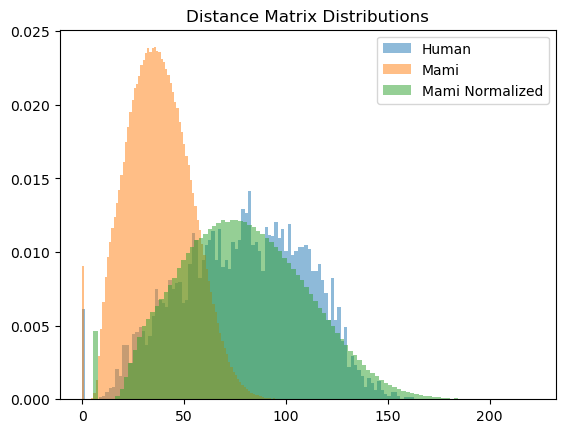

In [8]:
plt.hist(d_kayson.flatten(), bins=100, alpha=0.5, label="Human", density=True)
plt.hist(d_mami.flatten(), bins=100, alpha=0.5, label="Mami", density=True)
plt.hist(d_mami_normalized.flatten(), bins=100, alpha=0.5, label="Mami Normalized", density=True)
plt.legend()
plt.title("Distance Matrix Distributions")